In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import ks_2samp

data = pd.read_csv("../../../data/raw/kathmandu_full_raw_2023_2024.csv")
data["time"] = pd.to_datetime(data["time"])
data = data.sort_values("time").reset_index(drop=True)
data = data.set_index("time")

15 — Time-Series Decomposition: Splits the PM2.5 series into trend, seasonal (daily), and residual components to see how much of the variation is structural versus random.

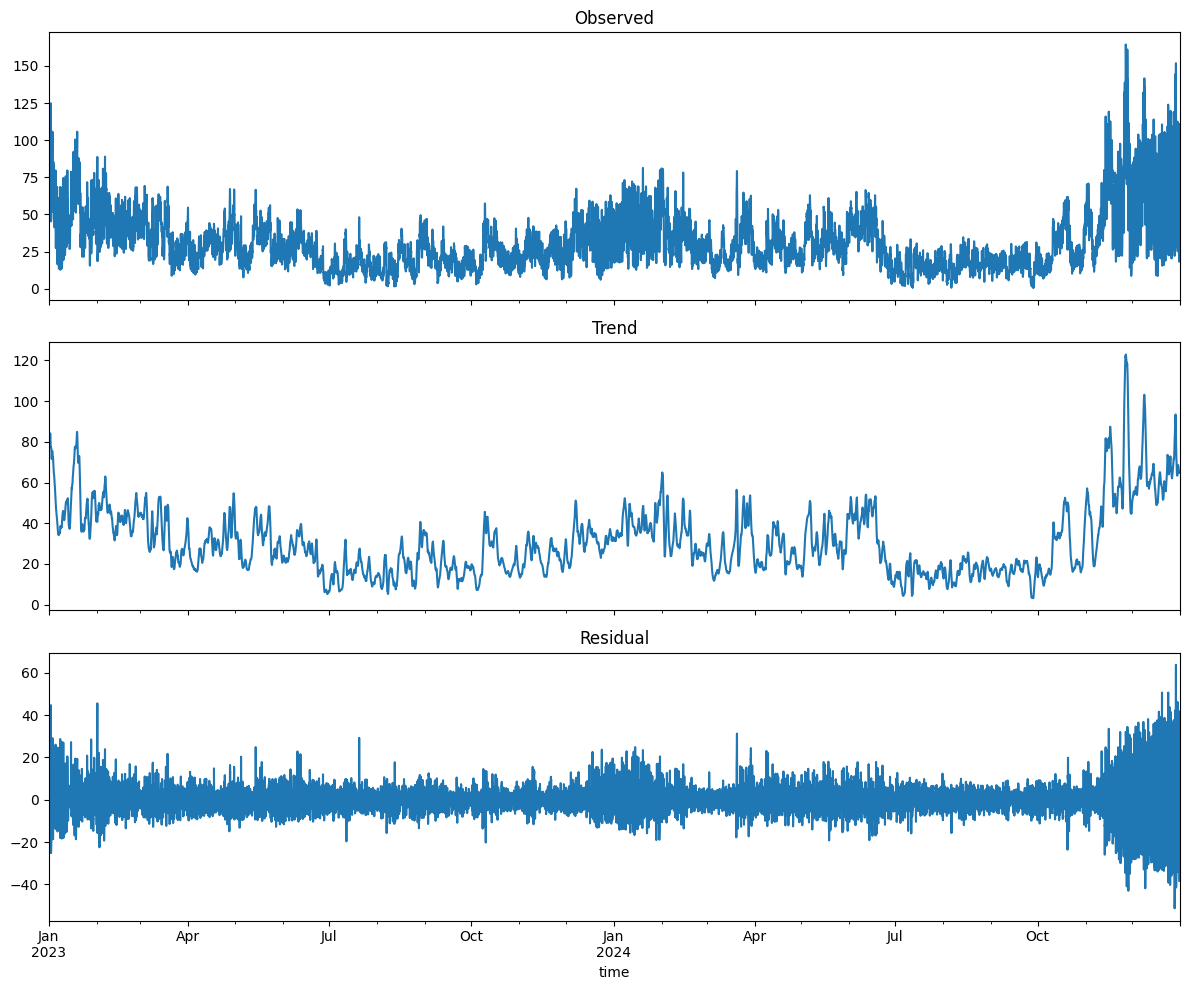

In [3]:
result = seasonal_decompose(data["pm2_5"], model="additive", period=24)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
result.observed.plot(ax=axes[0], title="Observed")
result.trend.plot(ax=axes[1], title="Trend")
result.resid.plot(ax=axes[2], title="Residual")
plt.tight_layout()
plt.show()

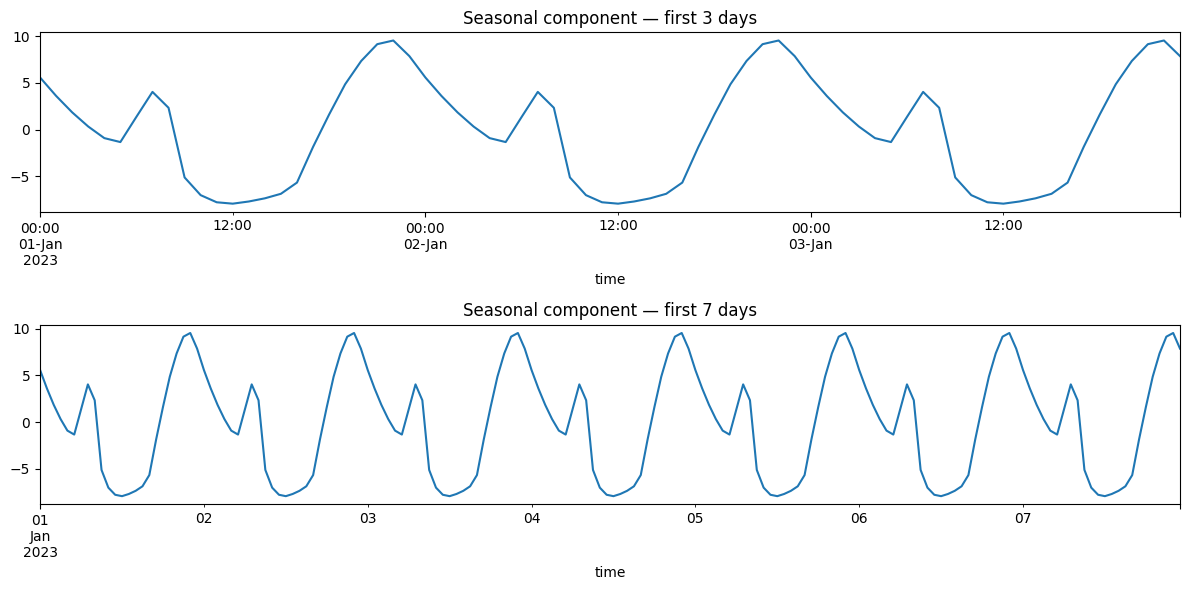

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
result.seasonal.iloc[:24*3].plot(ax=axes[0], title="Seasonal component — first 3 days")
result.seasonal.iloc[:24*7].plot(ax=axes[1], title="Seasonal component — first 7 days")
plt.tight_layout()
plt.show()

16 — Stationarity Testing (ADF/KPSS): Checks whether the statistical properties of PM2.5 (mean, variance) stay constant over time, which determines whether ARIMA-family models need differencing.


In [5]:
adf_stat, adf_p, *_ = adfuller(data["pm2_5"])
print(f"ADF Statistic: {adf_stat:.4f}, p-value: {adf_p:.4f}")
print("ADF conclusion:", "Stationary" if adf_p < 0.05 else "Non-stationary")

kpss_stat, kpss_p, *_ = kpss(data["pm2_5"], regression="c", nlags="auto")
print(f"\nKPSS Statistic: {kpss_stat:.4f}, p-value: {kpss_p:.4f}")
print("KPSS conclusion:", "Non-stationary" if kpss_p < 0.05 else "Stationary")

ADF Statistic: -5.8642, p-value: 0.0000
ADF conclusion: Stationary

KPSS Statistic: 1.4618, p-value: 0.0100
KPSS conclusion: Non-stationary


C:\Users\adars\AppData\Local\Temp\ipykernel_18708\3748553825.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(data["pm2_5"], regression="c", nlags="auto")


17 — Pearson Correlation: Measures the strength of linear relationships between PM2.5 and every other numeric variable.

In [6]:
numeric_cols = data.select_dtypes(include=[np.number]).columns
pearson_corr = data[numeric_cols].corr(method="pearson")

print("Pearson correlation with pm2_5:")
print(pearson_corr["pm2_5"].sort_values(ascending=False))

Pearson correlation with pm2_5:
pm2_5                   1.000000
pm10                    0.952177
sulphur_dioxide         0.753975
carbon_monoxide         0.620771
nitrogen_dioxide        0.493972
surface_pressure        0.175934
relative_humidity_2m    0.045576
ozone                  -0.019743
wind_direction_10m     -0.109160
wind_speed_10m         -0.110932
temperature_2m         -0.522716
Name: pm2_5, dtype: float64


18 — Spearman Correlation: Measures monotonic (not necessarily linear) relationships between PM2.5 and other variables, catching patterns Pearson might miss.


In [7]:
spearman_corr = data[numeric_cols].corr(method="spearman")

print("Spearman correlation with pm2_5:")
print(spearman_corr["pm2_5"].sort_values(ascending=False))

Spearman correlation with pm2_5:
pm2_5                   1.000000
pm10                    0.984206
sulphur_dioxide         0.660291
carbon_monoxide         0.628313
nitrogen_dioxide        0.412267
surface_pressure        0.218198
ozone                   0.050449
relative_humidity_2m   -0.047194
wind_direction_10m     -0.077613
wind_speed_10m         -0.078430
temperature_2m         -0.516114
Name: pm2_5, dtype: float64


19 — Correlation Heatmap: Visualizes the full Pearson correlation matrix across all variables at once, making it easy to spot the strongest relationships.

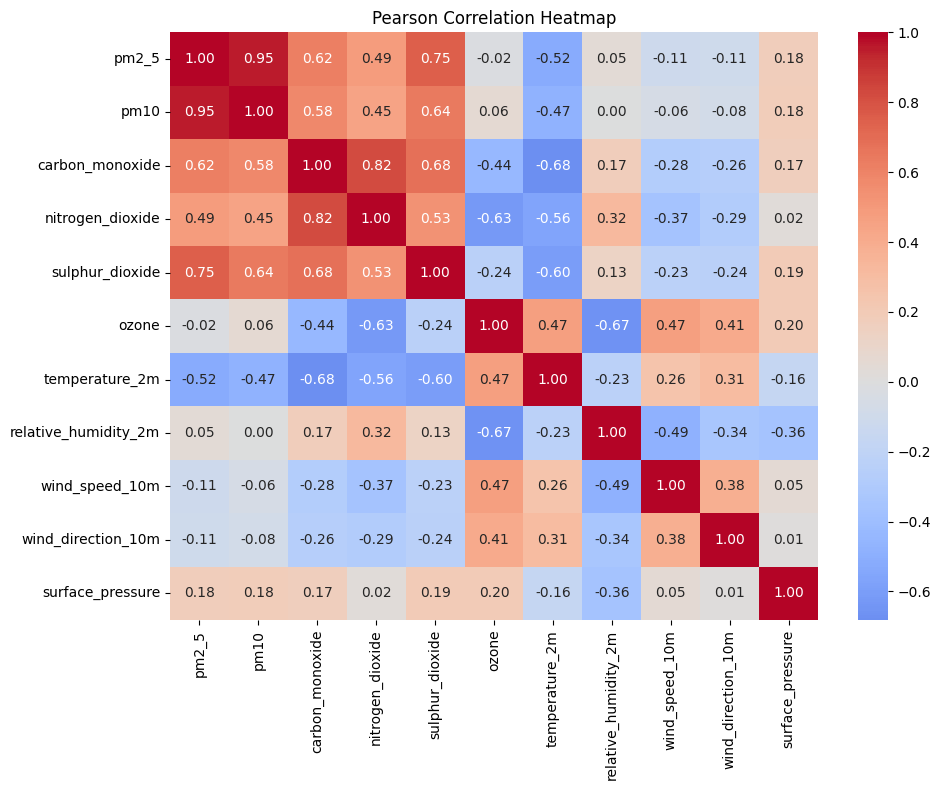

In [8]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
plt.show()

20 — ACF (Autocorrelation Function): Shows how strongly PM2.5 correlates with its own past values at every lag, revealing overall temporal dependency and periodicity.


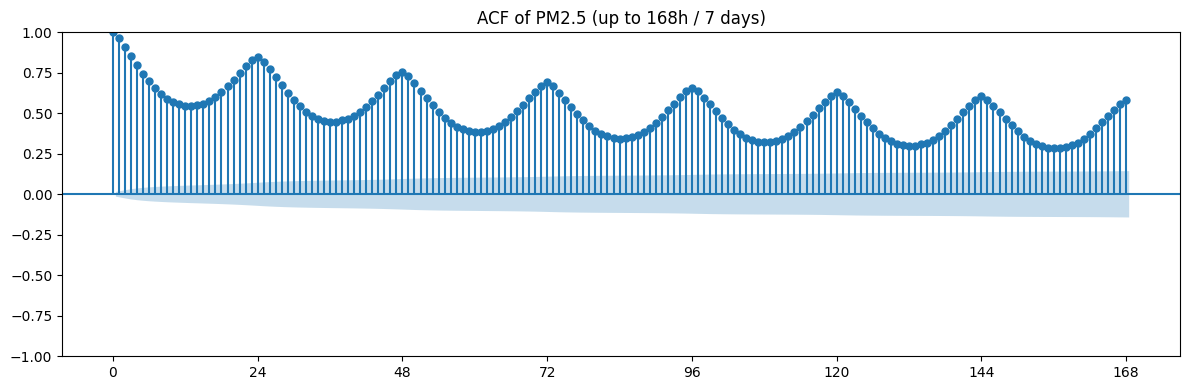

In [29]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(data["pm2_5"], lags=168, ax=ax)
ax.set_xticks(range(0, 169, 24))

plt.title("ACF of PM2.5 (up to 168h / 7 days)")
plt.tight_layout()
plt.show()

21 — PACF (Partial Autocorrelation Function): Shows the direct correlation between PM2.5 and a specific past lag, with the influence of intermediate lags removed — used to pick which lags actually matter.


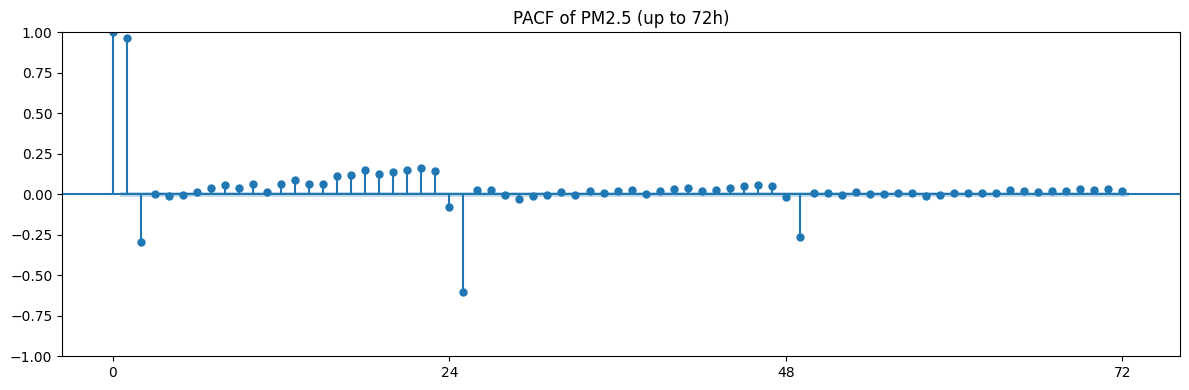

In [30]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_pacf(data["pm2_5"], lags=72, method="ywm", ax=ax)
ax.set_xticks(range(0, 73, 24))

plt.title("PACF of PM2.5 (up to 72h)")
plt.tight_layout()
plt.show()

22 — Lag Correlation Analysis: Quantifies PM2.5's correlation with itself at specific, chosen lags (1h, 24h, 168h, etc.) to confirm hourly/daily/weekly dependency.


Lag   1h : 0.9656
Lag   2h : 0.9122
Lag   3h : 0.8557
Lag   6h : 0.6984
Lag  12h : 0.5492
Lag  24h : 0.8559
Lag  48h : 0.7682
Lag 168h : 0.6118


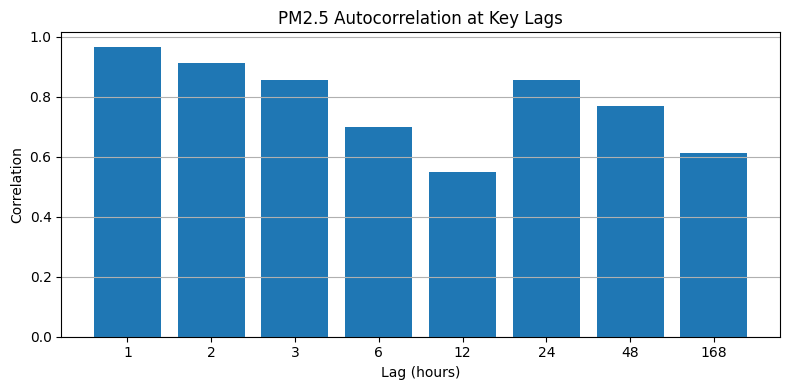

In [31]:
key_lags = [1, 2, 3, 6, 12, 24, 48, 168]
lag_corrs = {lag: data["pm2_5"].autocorr(lag=lag) for lag in key_lags}

for lag, corr in lag_corrs.items():
    print(f"Lag {lag:>3}h : {corr:.4f}")

plt.figure(figsize=(8, 4))
plt.bar([str(l) for l in key_lags], list(lag_corrs.values()))
plt.title("PM2.5 Autocorrelation at Key Lags")
plt.xlabel("Lag (hours)")
plt.ylabel("Correlation")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

23 — Cross-Correlation Analysis: Measures how a weather variable's past values correlate with PM2.5 now, to detect delayed cause-effect relationships (e.g., does temperature change precede pollution change).


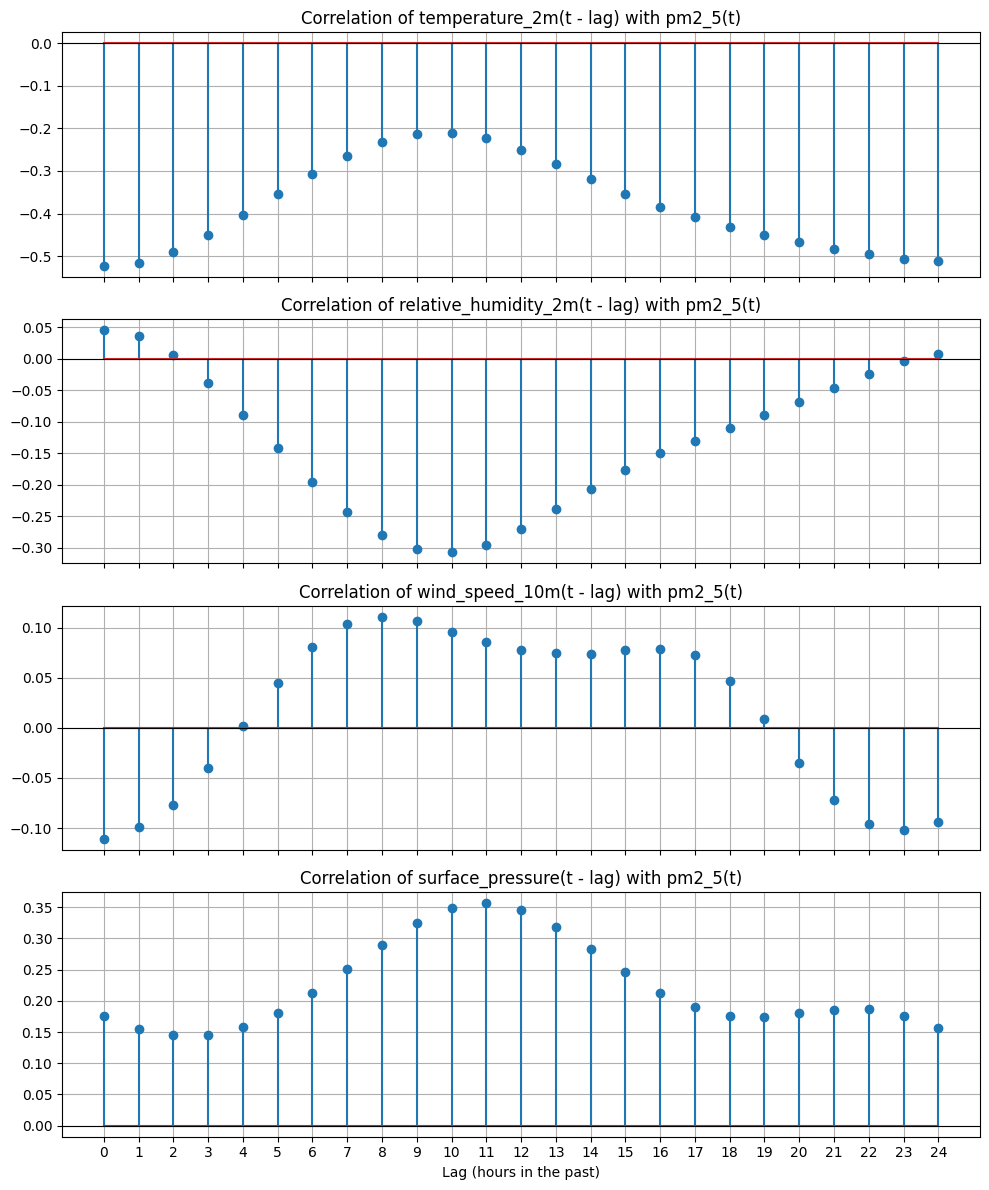

In [33]:
weather_vars = ["temperature_2m", "relative_humidity_2m", "wind_speed_10m", "surface_pressure"]
max_lag = 24

fig, axes = plt.subplots(len(weather_vars), 1, figsize=(10, 12), sharex=True)

for i, var in enumerate(weather_vars):
    lags = range(0, max_lag+1)
    # var.shift(k) = var's value k hours in the past, aligned against pm2_5 "now"
    corrs = [data[var].shift(k).corr(data["pm2_5"]) for k in lags]
    axes[i].stem(list(lags), corrs)
    axes[i].set_title(f"Correlation of {var}(t - lag) with pm2_5(t)")
    axes[i].axhline(0, color="black", linewidth=0.8)
    axes[i].grid(True)

axes[-1].set_xlabel("Lag (hours in the past)")
axes[-1].set_xticks(range(0, max_lag+1, 1))

plt.tight_layout()
plt.show()

24 — Multicollinearity Analysis (VIF): Detects which predictor variables are highly correlated with each other, which can destabilize linear model coefficients.


In [38]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

predictors = [
    "pm10", "carbon_monoxide", "nitrogen_dioxide", "sulphur_dioxide",
    "ozone", "temperature_2m", "relative_humidity_2m",
    "wind_speed_10m", "surface_pressure"
]

X = data[predictors].dropna()

# Add intercept
X = sm.add_constant(X)

vif_data = pd.DataFrame({
    "feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])]
})

# Remove the intercept row
vif_data = vif_data[vif_data["feature"] != "const"]

print(vif_data.sort_values("VIF", ascending=False))

                feature       VIF
2       carbon_monoxide  4.878414
3      nitrogen_dioxide  4.702051
5                 ozone  4.473152
1                  pm10  2.715856
7  relative_humidity_2m  2.447285
6        temperature_2m  2.431857
4       sulphur_dioxide  2.407515
8        wind_speed_10m  1.454668
9      surface_pressure  1.294020


25 — Temporal Feature Validation: Confirms that extracted time features (hour, day, month) are correctly and evenly distributed across the dataset.


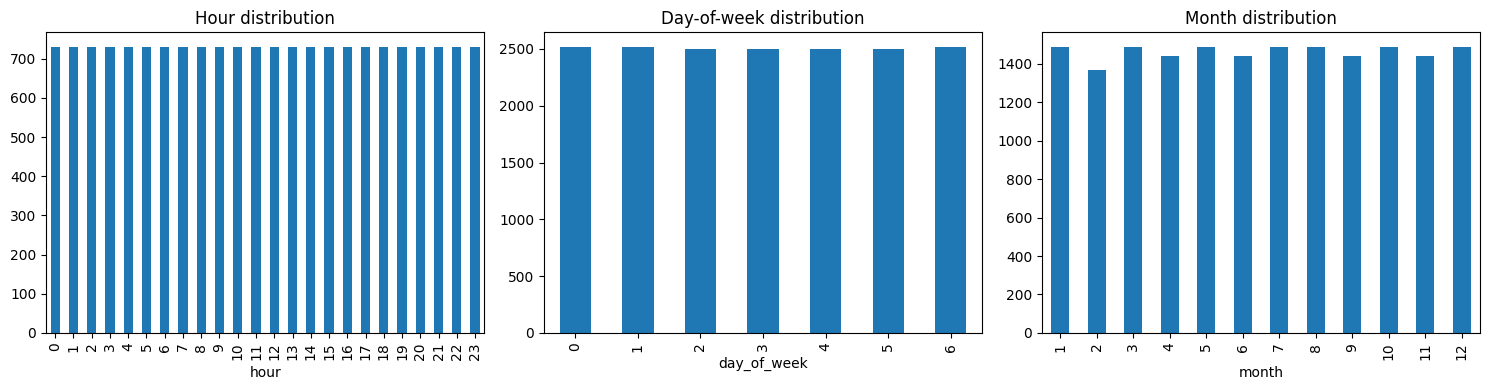

In [39]:
temp_check = data.copy()
temp_check["hour"] = temp_check.index.hour
temp_check["day_of_week"] = temp_check.index.dayofweek
temp_check["month"] = temp_check.index.month

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
temp_check["hour"].value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Hour distribution")
temp_check["day_of_week"].value_counts().sort_index().plot(kind="bar", ax=axes[1], title="Day-of-week distribution")
temp_check["month"].value_counts().sort_index().plot(kind="bar", ax=axes[2], title="Month distribution")
plt.tight_layout()
plt.show()

26 — Cyclical Encoding Validation: Checks that the sin/cos transformation of cyclical features (like hour or month) actually preserves or improves their relationship with PM2.5 compared to the raw values.


In [44]:
enc_check = data.copy()
enc_check["hour"] = enc_check.index.hour
enc_check["month"] = enc_check.index.month
enc_check["wind_dxn"] = enc_check["wind_direction_10m"]
enc_check["hour_sin"] = np.sin(2*np.pi*enc_check["hour"]/24)
enc_check["hour_cos"] = np.cos(2*np.pi*enc_check["hour"]/24)
enc_check["month_sin"] = np.sin(2*np.pi*enc_check["month"]/12)
enc_check["month_cos"] = np.cos(2*np.pi*enc_check["month"]/12)
enc_check["wind_dxn_sin"] = np.sin(2*np.pi*enc_check["wind_dxn"]/360)
enc_check["wind_dxn_cos"] = np.cos(2*np.pi*enc_check["wind_dxn"]/360)

print("Correlation with pm2_5:")
print("raw hour       :", enc_check["hour"].corr(enc_check["pm2_5"]))
print("hour_sin       :", enc_check["hour_sin"].corr(enc_check["pm2_5"]))
print("hour_cos       :", enc_check["hour_cos"].corr(enc_check["pm2_5"]))
print("raw month      :", enc_check["month"].corr(enc_check["pm2_5"]))
print("month_sin      :", enc_check["month_sin"].corr(enc_check["pm2_5"]))
print("month_cos      :", enc_check["month_cos"].corr(enc_check["pm2_5"]))
print("raw wind dxn   :", enc_check["wind_dxn"].corr(enc_check["pm2_5"]))
print("wind_dxn_sin   :", enc_check["wind_dxn_sin"].corr(enc_check["pm2_5"]))
print("wind_dxn_cos   :", enc_check["wind_dxn_cos"].corr(enc_check["pm2_5"]))

Correlation with pm2_5:
raw hour       : 0.055666275941760684
hour_sin       : -0.031577968387488435
hour_cos       : 0.2503847242451869
raw month      : -0.06698350045417437
month_sin      : 0.27681515373165727
month_cos      : 0.38718902383778747
raw wind dxn   : -0.10915978897362151
wind_dxn_sin   : 0.09582105669330435
wind_dxn_cos   : -0.2381289877498882


27 — Lag Feature Distribution Analysis: Visualizes how correlation strength decays as lag distance increases, confirming the lag features behave as expected.


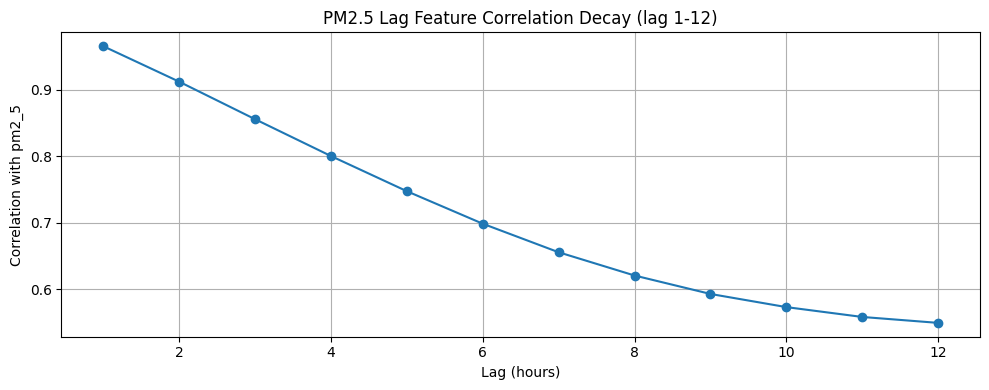

lag_1: 0.9656
lag_2: 0.9122
lag_3: 0.8557
lag_4: 0.8003
lag_5: 0.7473
lag_6: 0.6984
lag_7: 0.6554
lag_8: 0.6204
lag_9: 0.5927
lag_10: 0.5729
lag_11: 0.5581
lag_12: 0.5492


In [46]:
lag_range = range(1, 13)
lag_corrs_full = {i: data["pm2_5"].autocorr(lag=i) for i in lag_range}

plt.figure(figsize=(10, 4))
plt.plot(list(lag_corrs_full.keys()), list(lag_corrs_full.values()), marker="o")
plt.title("PM2.5 Lag Feature Correlation Decay (lag 1-12)")
plt.xlabel("Lag (hours)")
plt.ylabel("Correlation with pm2_5")
plt.grid(True)
plt.tight_layout()
plt.show()

for lag, corr in lag_corrs_full.items():
    print(f"lag_{lag}: {corr:.4f}")

28 — Train-Test Distribution Comparison: Statistically compares the train and test sets' distributions to check whether they represent different conditions (e.g., different seasons), which would bias evaluation.


      month_sin : KS stat = 0.6207, p-value = 0
      month_cos : KS stat = 0.3166, p-value = 1.367e-250
          pm2_5 : KS stat = 0.1740, p-value = 9.023e-75
 temperature_2m : KS stat = 0.0617, p-value = 9.999e-10


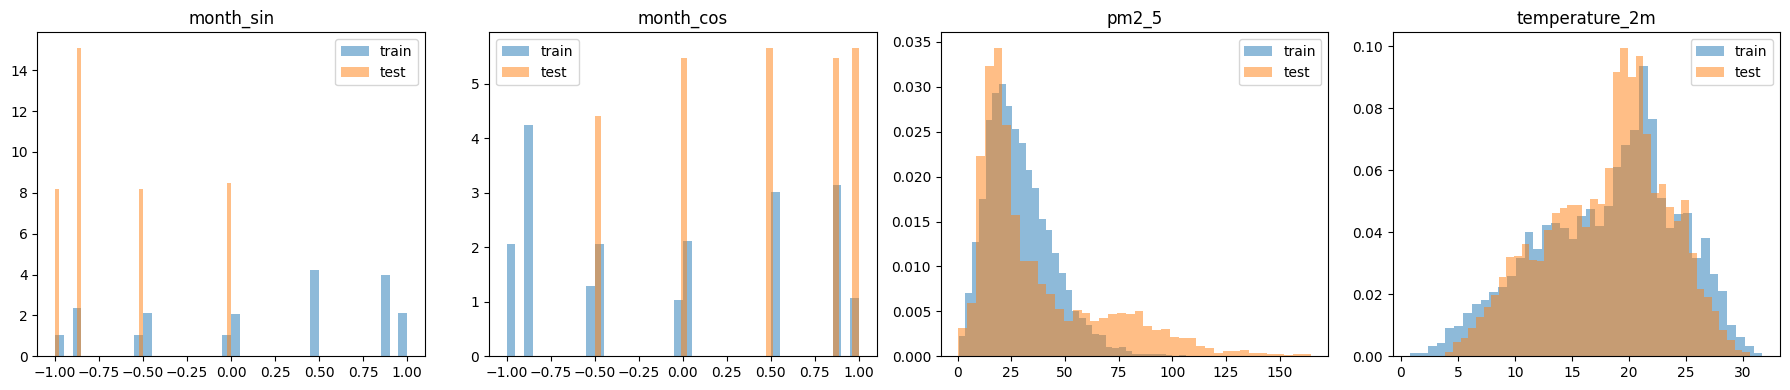

In [48]:
split = int(np.ceil(0.8 * len(data)))
train, test = data.iloc[:split], data.iloc[split:]

train_month = train.index.month
test_month = test.index.month

train_month_sin = np.sin(2*np.pi*train_month/12)
train_month_cos = np.cos(2*np.pi*train_month/12)
test_month_sin  = np.sin(2*np.pi*test_month/12)
test_month_cos  = np.cos(2*np.pi*test_month/12)

check_pairs = {
    "month_sin": (train_month_sin, test_month_sin),
    "month_cos": (train_month_cos, test_month_cos),
    "pm2_5": (train["pm2_5"], test["pm2_5"]),
    "temperature_2m": (train["temperature_2m"], test["temperature_2m"]),
}

for name, (tr, te) in check_pairs.items():
    stat, p = ks_2samp(tr, te)
    print(f"{name:>15} : KS stat = {stat:.4f}, p-value = {p:.4g}")

fig, axes = plt.subplots(1, len(check_pairs), figsize=(18, 4))
for i, (name, (tr, te)) in enumerate(check_pairs.items()):
    axes[i].hist(tr, bins=40, alpha=0.5, label="train", density=True)
    axes[i].hist(te, bins=40, alpha=0.5, label="test", density=True)
    axes[i].set_title(name)
    axes[i].legend()
plt.tight_layout()
plt.show()

29 — Baseline Forecast Analysis: Computes a naive "just predict the last value" forecast to give a minimum bar that any real model should beat.


30 — Extreme Pollution Event Analysis: Isolates the worst pollution events and examines when they happen and what conditions (season, hour, pollutants) accompany them.


31 — Feature Importance Pre-Analysis: Uses a quick tree-based model to rank which features contribute most to predicting PM2.5, as an initial sanity check before deeper analysis.


32 — SHAP/Explainability Analysis: Quantifies, per feature, exactly how much and in what direction it pushes individual PM2.5 predictions, giving the most rigorous "what actually drives this" answer.